### Feb 2025: END SEMESTER ASSESSMENT  
### M.TECH DATA SCIENCE AND MACHINE LEARNING_ SEMESTER II

##	UE20CS931 - MACHINE LEARNING - II

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from collections import Counter
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, learning_curve, train_test_split, KFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score,KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings ('ignore')

sns.set(style='white', context='notebook', palette='deep')

## Data description

This dataset contains information about employees in a company, including their educational backgrounds, work history, demographics, and employment-related factors. It has been anonymized to protect privacy while still providing valuable insights into the workforce.

Columns:

Education: The educational qualifications of employees, including degree, institution, and field of study.

Joining Year: The year each employee joined the company, indicating their length of service.

City: The location or city where each employee is based or works.

Payment Tier: Categorization of employees into different salary tiers.

Age: The age of each employee, providing demographic insights.

Gender: Gender identity of employees, promoting diversity analysis.

Ever Benched: Indicates if an employee has ever been temporarily without assigned work.

Experience in Current Domain: The number of years of experience employees have in their current field.

WorkHoursPerWeek: Work hours per week of the employee

AnnualBonus :  Annual gross bonus.

Leave or Not: a target column



In [3]:
df = pd.read_csv("dataset1.csv")
df.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot,WorkHoursPerWeek,AnnualBonus
0,Bachelors,2017,Bangalore,3,34.0,Male,No,0,0,41.236204,17736.470299
1,Bachelors,2013,Pune,1,28.0,Female,No,3,1,58.521429,10750.957116
2,Bachelors,2014,New Delhi,3,38.0,Female,No,2,0,51.959818,7524.178828
3,Masters,2016,Bangalore,3,27.0,Male,No,5,1,47.959755,17546.632887
4,Masters,2017,Pune,3,24.0,Male,Yes,2,1,34.680559,13233.644475


### 2(a).  Read the dataset and print the following (8 marks)
     (i) Describe the structure of a given dataset in terms of its shape, the number of numerical and categorical variables, and provide descriptive statistics for both types of variables. Additionally, mention any key observations based on the descriptive statistics. (5 mark)
      (ii) Summarize the categorical variables in a dataset by identifying the number of unique categories and the proportion of observations in each category. Highlight any noticeable patterns or anomalies. (3 mark)


### 2 (b). Examine missing values, outliers by plotting . Examine is the Target variable evenly balanced. (8 Marks)

In [6]:

# Summarize categorical variables (Categories and Proportions)
cat_cols = df.select_dtypes(include=['object', 'category']).columns
print("\n--- Categorical Variable Proportions ---")
for col in cat_cols:
    print(f"\nFeature: {col}")
    print(f"Unique Categories: {df[col].nunique()}")
    # Using '1' as a shorthand for the Boolean True to normalize
    print(df[col].value_counts(normalize=1))


--- Categorical Variable Proportions ---

Feature: Education
Unique Categories: 3
Education
Bachelors    0.773909
Masters      0.187621
PHD          0.038470
Name: proportion, dtype: float64

Feature: City
Unique Categories: 3
City
Bangalore    0.478831
Pune         0.272512
New Delhi    0.248657
Name: proportion, dtype: float64

Feature: Gender
Unique Categories: 2
Gender
Male      0.597034
Female    0.402966
Name: proportion, dtype: float64

Feature: EverBenched
Unique Categories: 2
EverBenched
No     0.898176
Yes    0.101824
Name: proportion, dtype: float64


--- Missing Values ---
Education                      0
JoiningYear                    0
City                           0
PaymentTier                    0
Age                          233
Gender                         0
EverBenched                   47
ExperienceInCurrentDomain      0
LeaveOrNot                     0
WorkHoursPerWeek               0
AnnualBonus                    0
dtype: int64


<Figure size 600x400 with 0 Axes>

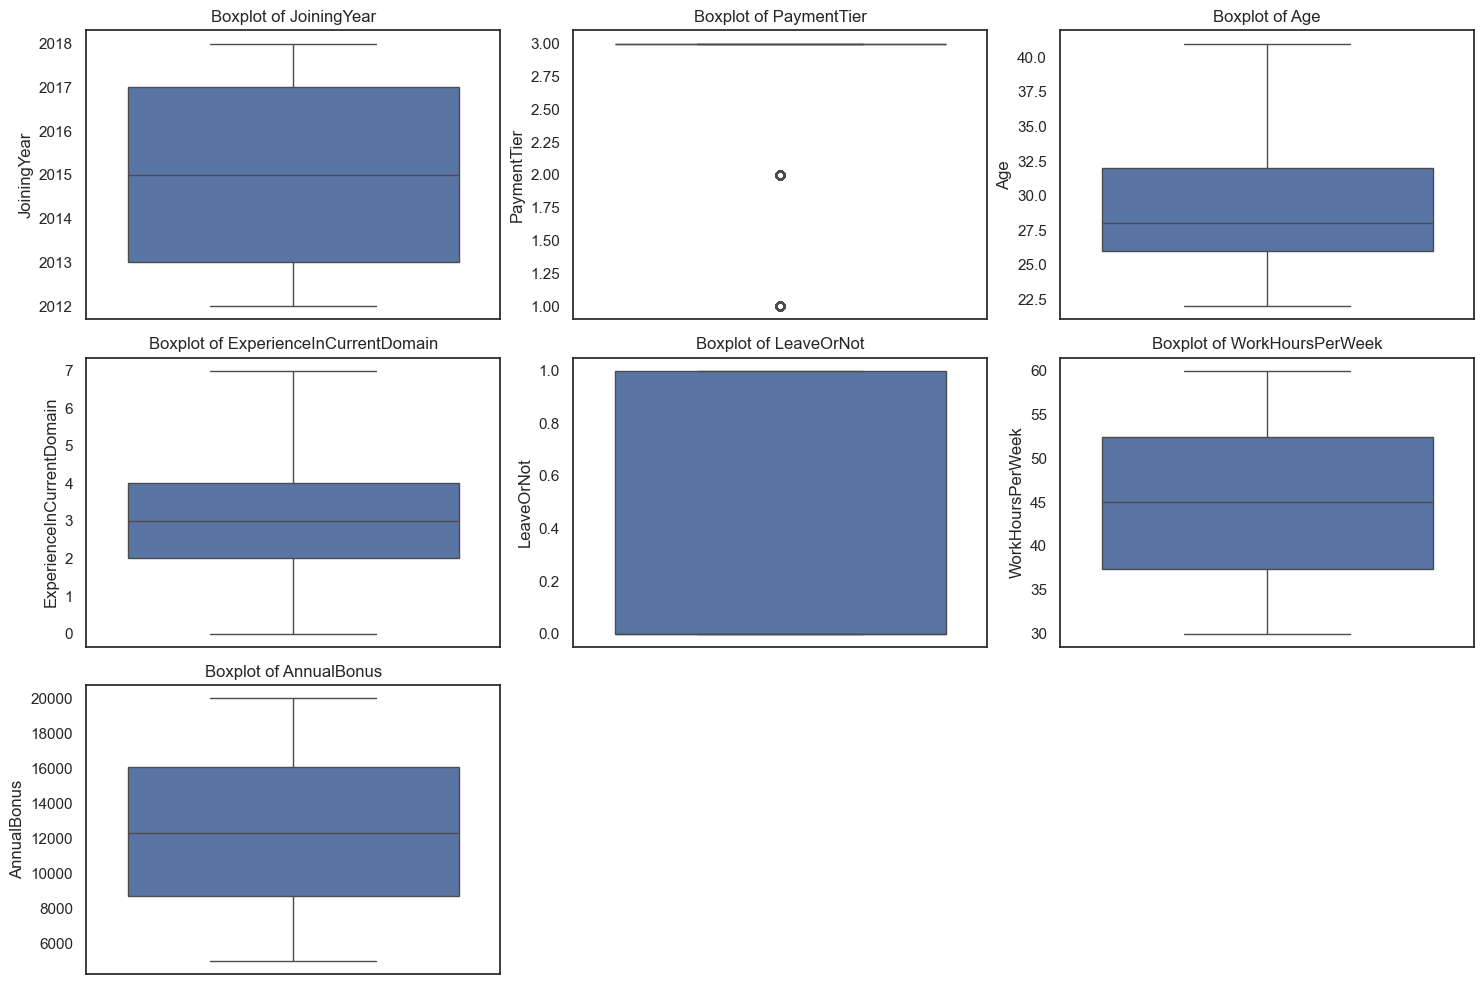

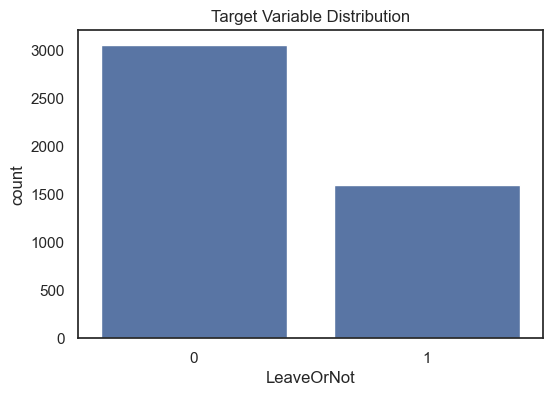

In [8]:
# Check missing values
print("--- Missing Values ---")
print(df.isnull().sum())

# Plotting outliers for numerical columns using boxplots
num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols)//3 + 1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# Examine Target variable balance (Replace 'Target' with your actual target column name)
target_col = 'LeaveOrNot' 
plt.figure(figsize=(6, 4))
sns.countplot(x=df[target_col])
plt.title('Target Variable Distribution')
plt.show()

### 2 (c).Perform appropriate encoding on the categorical attributes. (6 Marks)

In [12]:
df_encoded = df.copy()

# # Encoding target if it's categorical
# if df_encoded[target_col].dtype == 'object':
#     le = LabelEncoder()
#     df_encoded[target_col] = le.fit_transform(df_encoded[target_col])


df_encoded
# print(df_encoded.head())
# One-hot encode the rest of the categorical features
df_encoded = pd.get_dummies(df_encoded, drop_first=True)
print("Data shape after encoding:", df_encoded.shape)


df_encoded
# print(df_encoded.head())

Data shape after encoding: (4653, 13)


,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot,WorkHoursPerWeek,AnnualBonus,Education_Masters,Education_PHD,City_New Delhi,City_Pune,Gender_Male,EverBenched_Yes
0,2017,3,34.0,0,0,41.236204,17736.470299,False,False,False,False,True,False
1,2013,1,28.0,3,1,58.521429,10750.957116,False,False,False,True,False,False
2,2014,3,38.0,2,0,51.959818,7524.178828,False,False,True,False,False,False
3,2016,3,27.0,5,1,47.959755,17546.632887,True,False,False,False,True,False
4,2017,3,24.0,2,1,34.680559,13233.644475,True,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4648,2013,3,26.0,4,0,56.191294,12425.839185,False,False,False,False,False,False
4649,2013,2,37.0,2,1,35.065754,17698.017397,True,False,False,True,True,False
4650,2018,3,27.0,5,1,31.609044,12577.485673,True,False,True,False,True,False
4651,2012,3,30.0,2,0,51.523950,16220.521090,False,False,False,False,True,True


### 2(d) Perform necessary actions to ‘fix’  defects in the data  (8 marks)
(i) Impute the missing values using central values (Mean, median, mode)

(ii) Detect the outliers and decide if any treatment is required.

(iii) Detect the unnecessary features and remove.

In [16]:
# Impute missing values
# Numerical -> Median (robust to outliers), Categorical -> Mode
for col in df_encoded.columns:
    if df_encoded[col].isnull().sum() > 0:
        if df_encoded[col].dtype in ['int64', 'float64']:
            df_encoded[col].fillna(df_encoded[col].median(), inplace=True)
        else:
            df_encoded[col].fillna(df_encoded[col].mode()[0], inplace=True)

# Detect and treat outliers using IQR method for a specific feature (Example)
# You can loop this or apply to specific columns with high outliers seen in 2(b)
def cap_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[col] = np.where(data[col] > upper_bound, upper_bound, 
                 np.where(data[col] < lower_bound, lower_bound, data[col]))
    return data

for col in num_cols:
    if col != target_col:
        df_encoded = cap_outliers(df_encoded, col)

# Remove unnecessary features (e.g., ID columns - Replace 'EmployeeID' if applicable)
if 'EmployeeID' in df_encoded.columns:
    df_encoded.drop('EmployeeID', axis=1, inplace=True)

### 2(e). Examine the correlation and summarize the relationship between variables. Use appropriate plots to justify the same. (6 marks)               

### 2(f). Split dataset into train and test (70:30)  (4 marks)   

In [17]:
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop(target_col, axis=1)
y = df_encoded[target_col]

# Splitting 70:30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scaling numerical features (Optional but good for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train_scaled

X_train shape: (3257, 12), y_train shape: (3257,)
X_test shape: (1396, 12), y_test shape: (1396,)


array([[ 1.02897251,  0.        , -0.47953006, ...,  1.66292451,
         0.80308748, -0.33520649],
       [-0.58718091,  0.        , -0.69153351, ..., -0.60135021,
         0.80308748,  2.98323584],
       [ 1.02897251,  0.        , -1.11554041, ..., -0.60135021,
         0.80308748, -0.33520649],
       ...,
       [ 0.49025471,  0.        , -0.69153351, ..., -0.60135021,
         0.80308748,  2.98323584],
       [-0.58718091,  0.        , -0.69153351, ..., -0.60135021,
         0.80308748, -0.33520649],
       [-0.0484631 ,  0.        , -0.26752661, ..., -0.60135021,
         0.80308748, -0.33520649]])

### Section C (30 marks)

### 3 (a) Fit a Logistic Regression model and compare the results with respect to different threshold values. Please write your key observations based on F1 score for your model. (16 marks)

In [27]:
from sklearn.metrics import f1_score


model = LogisticRegression()
model = DecisionTreeClassifier()
model = RandomForestClassifier()

model.fit(X_train_scaled, y_train)

print(model.score(X_test_scaled, y_test))

ypred = model.predict(X_test_scaled)
model.score(X_test_scaled, y_test)

f1_score(ypred, y_test)

0.829512893982808


0.7132530120481928

In [28]:
dir(model)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_compute_oob_predictions',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_get_default_requests',
 '_get_doc_link',
 '_get_estimators_indices',
 '_get_metadata_request',
 '_get_oob_predictions',
 '_get_param_names',
 '_get_tags',
 '_make_estimator',
 '_more_tags',
 '_n_samples',
 '_n_samples_bootstrap',
 '_parameter_constraints',
 '_repr_

### 3 (b) Compare the performance of Logistic regression, Decision Tree and Random Forest on the given dataset. Analyze the results, clearly state the changes or optimizations you would make to each model before re-fitting, and justify your approach.  (16 Marks)

In [31]:
imp = model.feature_importances_
names = X.columns
impDf = pd.DataFrame({"Feature": names, "importance": imp})
impDf

,Feature,importance
0,JoiningYear,0.235627
1,PaymentTier,0.000000
2,Age,0.084523
3,ExperienceInCurrentDomain,0.053347
4,WorkHoursPerWeek,0.176171
5,AnnualBonus,0.177773
6,Education_Masters,0.062913
7,Education_PHD,0.005147
8,City_New Delhi,0.016749
9,City_Pune,0.082990


### 3 (c) Summarize the solution to the business problem as follows (8 marks):

* Feature Importance (4 marks): Identify and explain which features are most influential in solving the problem and why.

* Evaluation Metrics Performance (2 marks)Provide an analysis of the model's performance based on key evaluation metrics.

* Overall Results and Observations (2 marks): Summarize the overall findings, including key insights and their implications for the business problem.


In [32]:
help(GridSearchCV)

Help on class GridSearchCV in module sklearn.model_selection._search:

class GridSearchCV(BaseSearchCV)
 |  GridSearchCV(estimator, param_grid, *, scoring=None, n_jobs=None, refit=True, cv=None, verbose=0, pre_dispatch='2*n_jobs', error_score=nan, return_train_score=False)
 |
 |  Exhaustive search over specified parameter values for an estimator.
 |
 |  Important members are fit, predict.
 |
 |  GridSearchCV implements a "fit" and a "score" method.
 |  It also implements "score_samples", "predict", "predict_proba",
 |  "decision_function", "transform" and "inverse_transform" if they are
 |  implemented in the estimator used.
 |
 |  The parameters of the estimator used to apply these methods are optimized
 |  by cross-validated grid-search over a parameter grid.
 |
 |  Read more in the :ref:`User Guide <grid_search>`.
 |
 |  Parameters
 |  ----------
 |  estimator : estimator object
 |      This is assumed to implement the scikit-learn estimator interface.
 |      Either estimator needs